# ViSQOL — Real Dataset Evaluation

Evaluates the Rust ViSQOL Python bindings on two speech-quality datasets:

| Dataset | Type | Conditions | Samples |
|---------|------|-----------|--------|
| **Genspeech** | Neural speech codecs (LPCNet / OpusNet) | subjective MOS | 160 |
| **TCDvoip** | VoIP degradations (ECHO, CHOP, CLIP, COMPSPKR, NOISE) | subjective MOS | 384 |

Both datasets use ViSQOL **speech mode** (21 gammatone bands capped at 8 kHz, VAD-gated patches).

In [1]:
from pathlib import Path
import concurrent.futures
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import seaborn as sns

from audio_samples_qoe import visqol, VisqolError

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
warnings.filterwarnings("ignore")

DATASETS_ROOT = Path("/home/jmg/code/audio/datasets")

## Helper — score one pair

Returns `NaN` on error so the rest of the notebook still runs if a file is missing.

In [2]:
def score_pair(ref_path: Path, deg_path: Path) -> float:
    try:
        return visqol(str(ref_path), str(deg_path), mode="speech")
    except (VisqolError, OSError) as e:
        print(f"  SKIP {ref_path.name}: {e}")
        return float("nan")


def score_dataframe(df: pd.DataFrame, base: Path, ref_col: str, deg_col: str, workers: int = 4) -> pd.Series:
    """Score all rows in *df* in parallel, return a Series of predicted MOS."""
    pairs = [(base / row[ref_col], base / row[deg_col]) for _, row in df.iterrows()]
    with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(lambda p: score_pair(*p), pairs))
    return pd.Series(results, index=df.index, name="predicted_mos")

## Summary statistics helper

In [3]:
def summary(gt: pd.Series, pred: pd.Series, label: str = "") -> pd.DataFrame:
    mask = pred.notna() & gt.notna()
    g, p = gt[mask].values, pred[mask].values
    r, _ = stats.pearsonr(g, p)
    rho, _ = stats.spearmanr(g, p)
    rmse = np.sqrt(np.mean((p - g) ** 2))
    mae = np.mean(np.abs(p - g))
    bias = np.mean(p - g)
    row = dict(dataset=label, n=mask.sum(), pearson_r=r, spearman_rho=rho,
               rmse=rmse, mae=mae, bias=bias)
    return pd.DataFrame([row]).set_index("dataset")

---
## 1 · Genspeech

In [4]:
gen_df = pd.read_csv(DATASETS_ROOT / "genspeech/genspeech.csv")
print(f"{len(gen_df)} rows  |  columns: {list(gen_df.columns)}")
gen_df.head(3)

160 rows  |  columns: ['Ref_Wave', 'Test_Wave', 'MOS']


,Ref_Wave,Test_Wave,MOS
0,Genspeech/LPCNet_listening_test/mfall/dir1/ref...,Genspeech/LPCNet_listening_test/mfall/dir1/lpc...,3.823139
1,Genspeech/LPCNet_listening_test/vec18/dir1/ref...,Genspeech/LPCNet_listening_test/vec18/dir1/lpc...,4.122820
2,Genspeech/LPCNet_listening_test/mfall/dir2/ref...,Genspeech/LPCNet_listening_test/mfall/dir2/lpc...,4.312159


In [5]:
print("Scoring Genspeech …")
gen_df["predicted_mos"] = score_dataframe(
    gen_df, DATASETS_ROOT / "genspeech", "Ref_Wave", "Test_Wave"
)
print(f"Done — {gen_df['predicted_mos'].notna().sum()} / {len(gen_df)} scored")

Scoring Genspeech …


Done — 160 / 160 scored


In [6]:
# Derive a condition label from the path (mfall / vec18 × LPCNet / OpusNet)
def gen_label(path: str) -> str:
    parts = Path(path).parts
    # e.g. Genspeech/LPCNet_listening_test/mfall/dir1/lpcnq.wav
    test = parts[1].replace("_listening_test", "")   # LPCNet / OpusNet
    spk  = parts[2]                                  # mfall / vec18
    return f"{test}/{spk}"

gen_df["condition"] = gen_df["Test_Wave"].apply(gen_label)
gen_df[["Ref_Wave", "Test_Wave", "MOS", "predicted_mos", "condition"]].head()

,Ref_Wave,Test_Wave,MOS,predicted_mos,condition
0,Genspeech/LPCNet_listening_test/mfall/dir1/ref...,Genspeech/LPCNet_listening_test/mfall/dir1/lpc...,3.823139,3.896218,LPCNet/mfall
1,Genspeech/LPCNet_listening_test/vec18/dir1/ref...,Genspeech/LPCNet_listening_test/vec18/dir1/lpc...,4.122820,3.680956,LPCNet/vec18
2,Genspeech/LPCNet_listening_test/mfall/dir2/ref...,Genspeech/LPCNet_listening_test/mfall/dir2/lpc...,4.312159,4.007401,LPCNet/mfall
3,Genspeech/LPCNet_listening_test/vec18/dir2/ref...,Genspeech/LPCNet_listening_test/vec18/dir2/lpc...,3.054721,3.480332,LPCNet/vec18
4,Genspeech/LPCNet_listening_test/mfall/dir3/ref...,Genspeech/LPCNet_listening_test/mfall/dir3/lpc...,3.351932,3.652903,LPCNet/mfall


In [7]:
gen_stats = summary(gen_df["MOS"], gen_df["predicted_mos"], "Genspeech (all)")
gen_stats.round(4)

,n,pearson_r,spearman_rho,rmse,mae,bias
dataset,,,,,,
Genspeech (all),160,0.7244,0.7118,1.1697,0.903,0.7458


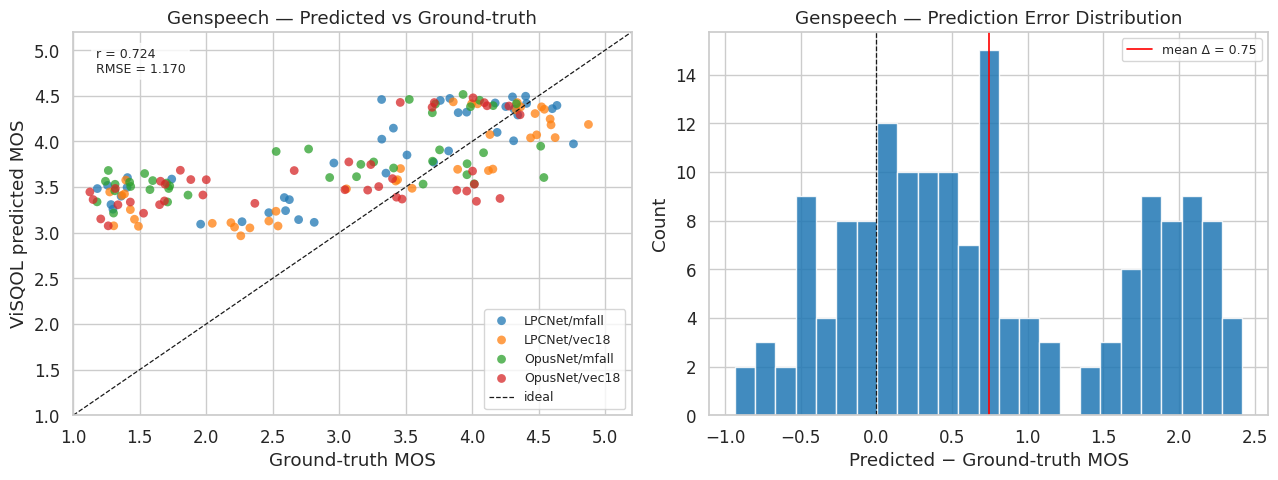

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — scatter: predicted vs ground-truth, coloured by condition
ax = axes[0]
palette = sns.color_palette("tab10", n_colors=gen_df["condition"].nunique())
for i, (cond, grp) in enumerate(gen_df.groupby("condition")):
    ax.scatter(grp["MOS"], grp["predicted_mos"], label=cond,
               color=palette[i], alpha=0.75, s=40, edgecolors="none")
lims = [1, 5.2]
ax.plot(lims, lims, "k--", lw=0.9, label="ideal")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Ground-truth MOS"); ax.set_ylabel("ViSQOL predicted MOS")
ax.set_title("Genspeech — Predicted vs Ground-truth")
ax.legend(fontsize=9, framealpha=0.8)

r = gen_stats.loc["Genspeech (all)", "pearson_r"]
rmse = gen_stats.loc["Genspeech (all)", "rmse"]
ax.text(0.04, 0.96, f"r = {r:.3f}\nRMSE = {rmse:.3f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

# — error distribution
ax2 = axes[1]
err = gen_df["predicted_mos"] - gen_df["MOS"]
ax2.hist(err.dropna(), bins=25, color=palette[0], edgecolor="white", alpha=0.85)
ax2.axvline(0, color="k", lw=0.9, linestyle="--")
ax2.axvline(err.mean(), color="red", lw=1.2, linestyle="-", label=f"mean Δ = {err.mean():.2f}")
ax2.set_xlabel("Predicted − Ground-truth MOS")
ax2.set_ylabel("Count")
ax2.set_title("Genspeech — Prediction Error Distribution")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("genspeech_eval.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Per-condition stats
rows = []
for cond, grp in gen_df.groupby("condition"):
    rows.append(summary(grp["MOS"], grp["predicted_mos"], cond))
pd.concat(rows).round(4)

,n,pearson_r,spearman_rho,rmse,mae,bias
dataset,,,,,,
LPCNet/mfall,40,0.7992,0.7627,1.0600,0.7772,0.6911
LPCNet/vec18,40,0.8370,0.7657,0.9676,0.7110,0.4832
OpusNet/mfall,40,0.6718,0.6822,1.3535,1.0995,0.9584
OpusNet/vec18,40,0.5967,0.5702,1.2575,1.0243,0.8507


---
## 2 · TCDvoip

In [10]:
tcd_df = pd.read_csv(DATASETS_ROOT / "tcdvoip/tcdvoip.csv", index_col=0)
print(f"{len(tcd_df)} rows  |  columns: {list(tcd_df.columns)}")
tcd_df.head(3)

384 rows  |  columns: ['Ref_Wave', 'Test_Wave', 'Mushra_Scores', 'Utterance', 'Folder', 'Condition', 'Codec', 'Rate_kbps', 'sampleMOS', 'conditionMOS', 'conditionCI', 'DataBase', 'sampleSTD', 'sampleCI', 'Degradation', 'sumVotes', 'CodecCombination', 'Q_Value_dB', 'EXP', 'NoiseType', 'ErrorType', 'ErrorRate%']


,Ref_Wave,Test_Wave,Mushra_Scores,Utterance,Folder,Condition,Codec,Rate_kbps,sampleMOS,conditionMOS,...,sampleSTD,sampleCI,Degradation,sumVotes,CodecCombination,Q_Value_dB,EXP,NoiseType,ErrorType,ErrorRate%
Item,,,,,,,,,,,,,,,,,,,,,
NaN,TCDvoip/Test_Set/ECHO/ref/R_01_ECHO_FA.wav,TCDvoip/Test_Set/ECHO/C_01_ECHO_FA.wav,NaN,NaN,NaN,1,NaN,NaN,4.583333,4.677083,...,0.653863,0.261600,ECHO,110.0,NaN,NaN,NaN,NaN,NaN,NaN
NaN,TCDvoip/Test_Set/ECHO/ref/R_01_ECHO_FG.wav,TCDvoip/Test_Set/ECHO/C_01_ECHO_FG.wav,NaN,NaN,NaN,1,NaN,NaN,4.708333,4.677083,...,0.464306,0.185761,ECHO,113.0,NaN,NaN,NaN,NaN,NaN,NaN
NaN,TCDvoip/Test_Set/ECHO/ref/R_01_ECHO_MK.wav,TCDvoip/Test_Set/ECHO/C_01_ECHO_MK.wav,NaN,NaN,NaN,1,NaN,NaN,4.875000,4.677083,...,0.337832,0.135161,ECHO,117.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print("Scoring TCDvoip …")
tcd_df["predicted_mos"] = score_dataframe(
    tcd_df, DATASETS_ROOT / "tcdvoip", "Ref_Wave", "Test_Wave"
)
print(f"Done — {tcd_df['predicted_mos'].notna().sum()} / {len(tcd_df)} scored")

Scoring TCDvoip …


Done — 384 / 384 scored


In [12]:
tcd_stats = summary(tcd_df["sampleMOS"], tcd_df["predicted_mos"], "TCDvoip (all)")
tcd_stats.round(4)

,n,pearson_r,spearman_rho,rmse,mae,bias
dataset,,,,,,
TCDvoip (all),384,0.659,0.754,1.393,1.1863,1.1744


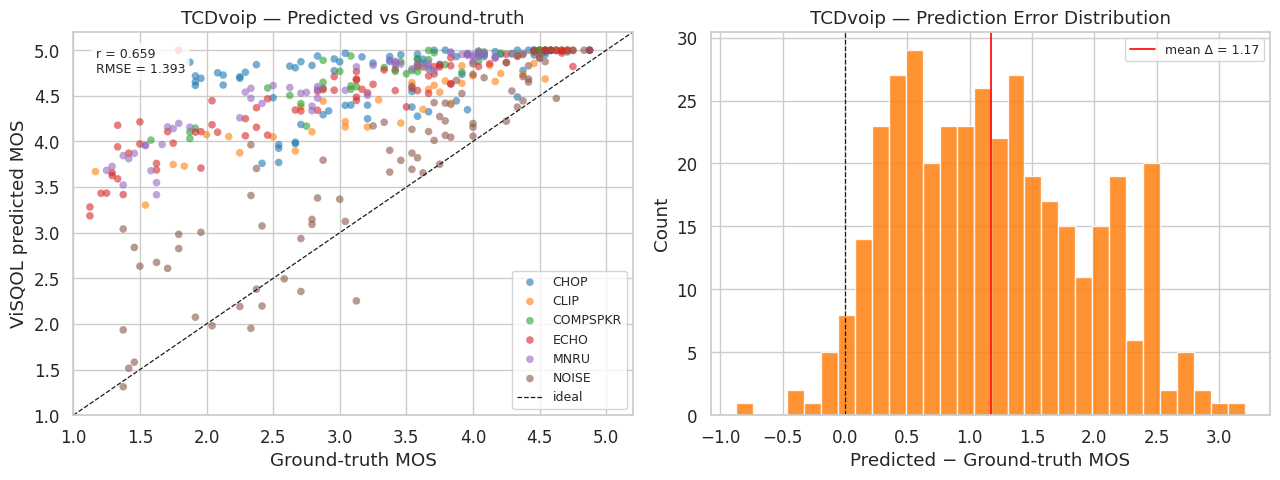

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette_tcd = sns.color_palette("tab10", n_colors=tcd_df["Degradation"].nunique())

ax = axes[0]
for i, (deg, grp) in enumerate(tcd_df.groupby("Degradation")):
    ax.scatter(grp["sampleMOS"], grp["predicted_mos"], label=deg,
               color=palette_tcd[i], alpha=0.6, s=30, edgecolors="none")
lims = [1, 5.2]
ax.plot(lims, lims, "k--", lw=0.9, label="ideal")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Ground-truth MOS"); ax.set_ylabel("ViSQOL predicted MOS")
ax.set_title("TCDvoip — Predicted vs Ground-truth")
ax.legend(fontsize=9, framealpha=0.8)

r = tcd_stats.loc["TCDvoip (all)", "pearson_r"]
rmse = tcd_stats.loc["TCDvoip (all)", "rmse"]
ax.text(0.04, 0.96, f"r = {r:.3f}\nRMSE = {rmse:.3f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

ax2 = axes[1]
err = tcd_df["predicted_mos"] - tcd_df["sampleMOS"]
ax2.hist(err.dropna(), bins=30, color=palette_tcd[1], edgecolor="white", alpha=0.85)
ax2.axvline(0, color="k", lw=0.9, linestyle="--")
ax2.axvline(err.mean(), color="red", lw=1.2, linestyle="-", label=f"mean Δ = {err.mean():.2f}")
ax2.set_xlabel("Predicted − Ground-truth MOS")
ax2.set_ylabel("Count")
ax2.set_title("TCDvoip — Prediction Error Distribution")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("tcdvoip_eval.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Per-degradation stats
rows = []
for deg, grp in tcd_df.groupby("Degradation"):
    rows.append(summary(grp["sampleMOS"], grp["predicted_mos"], deg))
pd.concat(rows).round(4)

,n,pearson_r,spearman_rho,rmse,mae,bias
dataset,,,,,,
CHOP,80,0.4537,0.6391,1.5225,1.3208,1.3208
CLIP,40,0.9365,0.9363,1.1742,1.0309,1.0309
COMPSPKR,40,0.8909,0.8838,1.4387,1.3348,1.3348
ECHO,80,0.9004,0.9112,1.6149,1.4306,1.4306
MNRU,64,0.9400,0.9369,1.6793,1.5768,1.5768
NOISE,80,0.8955,0.9112,0.6384,0.4984,0.4415


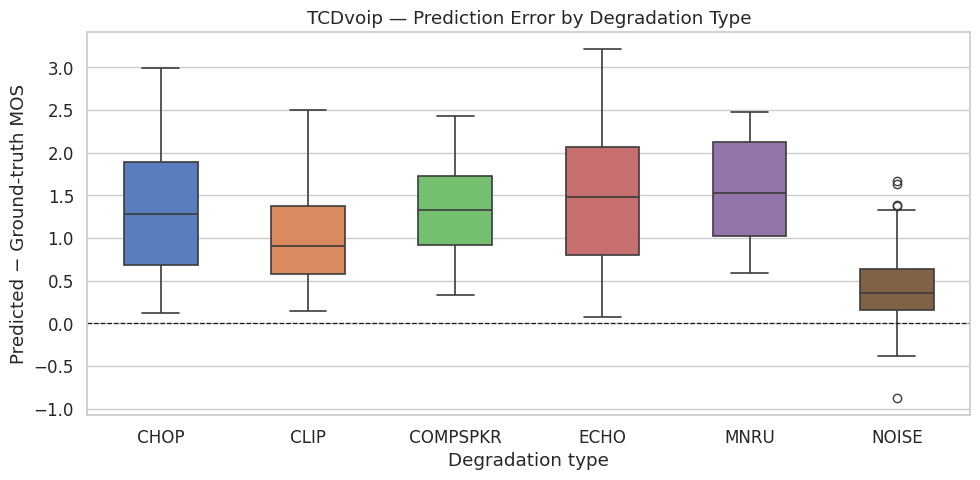

In [15]:
# Box plot: error per degradation type
tcd_df["error"] = tcd_df["predicted_mos"] - tcd_df["sampleMOS"]

fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(tcd_df["Degradation"].unique())
sns.boxplot(data=tcd_df, x="Degradation", y="error", order=order,
            palette="muted", ax=ax, width=0.5, linewidth=1.2)
ax.axhline(0, color="k", lw=0.9, linestyle="--")
ax.set_xlabel("Degradation type")
ax.set_ylabel("Predicted − Ground-truth MOS")
ax.set_title("TCDvoip — Prediction Error by Degradation Type")
plt.tight_layout()
plt.savefig("tcdvoip_error_by_degradation.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 · Combined summary

In [16]:
combined = pd.concat([gen_stats, tcd_stats])
combined.round(4)

,n,pearson_r,spearman_rho,rmse,mae,bias
dataset,,,,,,
Genspeech (all),160,0.7244,0.7118,1.1697,0.9030,0.7458
TCDvoip (all),384,0.6590,0.7540,1.3930,1.1863,1.1744


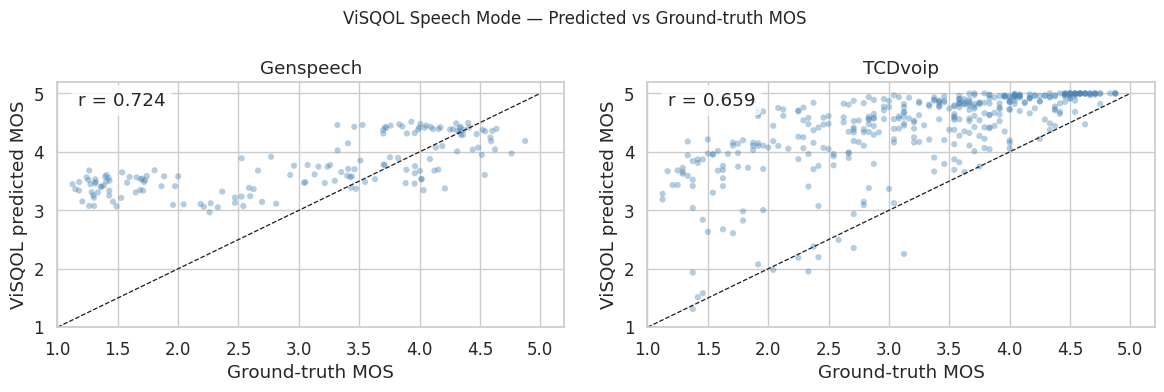

In [17]:
# MOS range coverage — are predictions bounded correctly?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, gt_col, title) in zip(axes, [
    (gen_df, "MOS",       "Genspeech"),
    (tcd_df, "sampleMOS", "TCDvoip"),
]):
    ax.scatter(df[gt_col], df["predicted_mos"],
               alpha=0.4, s=20, edgecolors="none", color="steelblue")
    ax.plot([1, 5], [1, 5], "k--", lw=0.9)
    ax.set_xlim(1, 5.2); ax.set_ylim(1, 5.2)
    ax.set_xlabel("Ground-truth MOS")
    ax.set_ylabel("ViSQOL predicted MOS")
    ax.set_title(title)
    r, _ = stats.pearsonr(df[gt_col].dropna(), df["predicted_mos"].dropna())
    ax.text(0.04, 0.96, f"r = {r:.3f}", transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

fig.suptitle("ViSQOL Speech Mode — Predicted vs Ground-truth MOS", fontsize=12)
plt.tight_layout()
plt.savefig("combined_scatter.png", dpi=150, bbox_inches="tight")
plt.show()